### Error estimations using Richardson extrapolation

Let $y_{\delta_t}(t)$ the solution obtained numerically. Errors are estimated as shown:

#### Forward/Backward Euler

$$
    E(t) = 2 \, \left| y_{\frac{\delta_t}{2}}(t) - y_{\delta_t}(t) \right| \qquad Q = \left| \frac{y_{\frac{\delta_t}{2}}(t) - y_{\delta_t}(t)}{y_{\frac{\delta_t}{4}}(t) - y_{\frac{\delta_t}{2}}(t)} \right| \approx 2
$$

#### Crank–Nicolson method

$$
    E(t) = \frac{4}{3} \, \left| y_{\frac{\delta_t}{2}}(t) - y_{\delta_t}(t) \right| \qquad Q = \left| \frac{y_{\frac{\delta_t}{2}}(t) - y_{\delta_t}(t)}{y_{\frac{\delta_t}{4}}(t) - y_{\frac{\delta_t}{2}}(t)} \right| \approx 4
$$

$Q$ is the quality factor

*General formulas can be found in the PDF folder*

In [1]:
import numpy as np
from scipy.optimize import fixed_point # Solves g(x0) = x0
import matplotlib.pyplot as plt

In [2]:
def extrapolation(f, t_ini, t_fin, delta_t, y_ini, method): # Implements the extrapolation method to compute the error

    if method == 'forward':
        
        def euler_forward(f, t_ini, t_fin, delta_t, y_ini): # Implements the forward Euler method
            N = round((t_fin - t_ini) / delta_t) # Compute total number of steps
            t = np.linspace(t_ini, t_fin, N + 1, endpoint = True) # Time discretization
            y = np.empty(N + 1) # y is the solution array
            y[0] = y_ini # Initial value
            dt = delta_t
            func = f
            for j in range(N): # Euler forward method applied
                y[j + 1] = y[j] + dt * func(t[j], y[j])
            
            return y # Returns only the solution

        sol1 = euler_forward(f, t_ini, t_fin, delta_t, y_ini) # sol delta_t
        sol2 = euler_forward(f, t_ini, t_fin, delta_t / 2.0, y_ini)[::2] # sol delta_t / 2
        sol4 = euler_forward(f, t_ini, t_fin, delta_t / 4.0, y_ini)[::4] # sol delta_t / 4

        error = 2.0 * np.abs(sol2 - sol1)
        Q_diff = 2.0 - np.abs((sol2 - sol1) / (sol4 - sol2 + 1e-16))

    if method == 'backward':
        
        def euler_backward(f, t_ini, t_fin, delta_t, y_ini): # Implements the backward Euler method
            N = round((t_fin - t_ini) / delta_t)
            t = np.linspace(t_ini, t_fin, N + 1, endpoint = True)
            y = np.empty(N + 1)
            y[0] = y_ini
            dt = delta_t

            implicit_equation = lambda y_new, y_old, t_new: 2.0 * y_new - y_old - dt * f(t_new, y_new) # Implicit equation: y_new - y_old - dt * f(t_new, y_new) = 0

            for j in range(N):
                t_new = t[j + 1]
                y_old = y[j]
                y_guess = y_old # Initial guess: use y_old
                y_new = fixed_point( # Using fixed_point from scipy
                    func = implicit_equation,
                    x0 = y_guess,
                    args = (y_old, t_new),
                    xtol = 1e-07
                )

                y[j + 1] = y_new
            
            return y

        sol1 = euler_backward(f, t_ini, t_fin, delta_t, y_ini)
        sol2 = euler_backward(f, t_ini, t_fin, delta_t / 2.0, y_ini)[::2]
        sol4 = euler_backward(f, t_ini, t_fin, delta_t / 4.0, y_ini)[::4]

        error = 2.0 * np.abs(sol2 - sol1)
        Q_diff = 2.0 - np.abs((sol2 - sol1) / (sol4 - sol2 + 1e-16))

    if method == 'CN':

        def CN(f, t_ini, t_fin, delta_t, y_ini): # Implements the Crank–Nicolson method
            N = round((t_fin - t_ini) / delta_t)
            t = np.linspace(t_ini, t_fin, N + 1, endpoint = True)
            y = np.empty(N + 1)
            y[0] = y_ini
            dt = delta_t

            implicit_equation = lambda y_new, y_old, t_new, t_old: 2.0 * y_new - y_old - dt / 2.0 * (f(t_new, y_new) + f(t_old, y_old)) # Implicit equation: y_new - y_old - dt / 2 * [f(t_new, y_new) + f(t_old, y_old)] = 0

            for j in range(N):
                t_old = t[j]
                t_new = t[j + 1]
                y_old = y[j]
                y_guess = y_old # Initial guess: use y_old
                y_new = fixed_point( # Using fixed_point from scipy
                    func = implicit_equation,
                    x0 = y_guess,
                    args = (y_old, t_new, t_old),
                    xtol = 1e-06
                )

                y[j + 1] = y_new
            
            return y

        sol1 = CN(f, t_ini, t_fin, delta_t, y_ini)
        sol2 = CN(f, t_ini, t_fin, delta_t / 2.0, y_ini)[::2]
        sol4 = CN(f, t_ini, t_fin, delta_t / 4.0, y_ini)[::4]

        error = 4.0 / 3.0 * np.abs(sol2 - sol1)
        Q_diff = 4.0 - np.abs((sol2 - sol1) / (sol4 - sol2 + 1e-16))

    return sol1, error, Q_diff # Returns y_h, error_h, Q_diff = 2 - Q_h

################################################################################

def plot_extrapolation_results(f, t_ini, t_fin, delta_t, y_ini): # Plot function

    t = np.linspace(t_ini, t_fin, round((t_fin - t_ini) / delta_t) + 1, endpoint = True) # Time grid for the coarse solution

    methods = ['forward', 'backward', 'CN']
    titles = [f'Forward Euler dt = {delta_t}', f'Backward Euler dt = {delta_t}', f'Crank–Nicolson dt = {delta_t}']

    _, axes = plt.subplots(1, 3, figsize = (15, 5))

    for ax, method, title in zip(axes, methods, titles):

        sol, error, _ = extrapolation(f, t_ini, t_fin, delta_t, y_ini, method) # Compute solution and error estimate

        # Plot the solution with error bars (shaded region)
        ax.plot(t, sol, '--o', label = 'Solution', color = 'blue', markersize = 4)
        ax.fill_between(t, sol - error, sol + error, color = 'red', alpha = 0.5, label='Error bounds')

        ax.set_title(title)
        ax.set_xlabel('t')
        ax.set_ylabel('y')
        ax.grid(True, linestyle = '--', alpha = 0.75, color = 'gray')
        ax.legend()

    plt.tight_layout()
    plt.show()

###########################################################################

def plot_Q(f, t_ini, t_fin, delta_t, y_ini): # Plot quality factor function

    t = np.linspace(t_ini, t_fin, round((t_fin - t_ini) / delta_t) + 1, endpoint = True) # Time grid for the coarse solution

    methods = ['forward', 'backward', 'CN']
    titles = [f'Q Forward Euler dt = {delta_t}', f'Q Backward Euler dt = {delta_t}', f' Q Crank–Nicolson dt = {delta_t}']

    _, axes = plt.subplots(1, 3, figsize = (15, 5))

    for ax, method, title in zip(axes, methods, titles):

        _, _, Q_diff = extrapolation(f, t_ini, t_fin, delta_t, y_ini, method) # Compute only Q_diff

        # Plotting
        ax.plot(t, Q_diff, '--o', label = r'Q deviation', color = 'black', markersize = 4)
        ax.axhline(y = 0.0, label = r'Optimal ($\Delta$Q = 0)', color = 'red', linestyle = '--', linewidth = 1.0)
        ax.set_title(title)
        ax.set_xlabel('t')
        ax.set_ylabel(r'$\Delta$Q')
        ax.grid(True, linestyle = '--', alpha = 0.75, color = 'gray')
        ax.legend()

    plt.tight_layout()
    plt.show()

Let's test:

\begin{cases}
    y'(t) = \frac{1}{2} \, y(t) \, t \, \cos(y(t)) \, \sin(t) \\
    y(0) = 1
\end{cases}


We choose initially $\delta t = 0.1$

In [3]:
f = lambda t, y: 0.5 * y * t * np.cos(y) * np.sin(t) # Differential equation

t_ini, t_fin = 0.0, 6.0 # t span = (0, 6)
delta_t = 0.1 # delta_t = 0.1
y_ini = 1.0 # y(0) = 1

In [4]:
extrapolation(f, t_ini, t_fin, delta_t, y_ini, method = 'forward')

(array([1.        , 1.        , 1.0002697 , 1.00134295, 1.00373621,
        1.00793539, 1.01438178, 1.02345684, 1.03546625, 1.05062305,
        1.06903015, 1.09066338, 1.11535658, 1.14279196, 1.1724994 ,
        1.20386892, 1.2361793 , 1.26864309, 1.30046469, 1.33090341,
        1.35933119, 1.38527468, 1.40843485, 1.42868279, 1.44603574,
        1.46062093, 1.4726352 , 1.48230706, 1.48986511, 1.49551378,
        1.49941583, 1.5016795 , 1.5023479 , 1.50138821, 1.49867804,
        1.49398681, 1.48694942, 1.47703014, 1.46347474, 1.44525079,
        1.42098031, 1.38887824, 1.34672837, 1.2919582 , 1.22191423,
        1.13446597, 1.029015  , 0.90774123, 0.77644748, 0.64401574,
        0.52005149, 0.41186149, 0.32275903, 0.25245001, 0.19853675,
        0.15792649, 0.12766634, 0.10528437, 0.08885197, 0.07692776,
        0.06846821]),
 array([0.00000000e+00, 6.75096510e-05, 4.03309760e-04, 9.99904700e-04,
        1.84262161e-03, 2.90858548e-03, 4.16573329e-03, 5.57176969e-03,
        7.07306420

In [5]:
extrapolation(f, t_ini, t_fin, delta_t, y_ini, method = 'backward')

(array([1.        , 1.00026966, 1.00134227, 1.00373227, 1.00792122,
        1.01434257, 1.02336539, 1.03527705, 1.0502652 , 1.0683999 ,
        1.08961765, 1.11371018, 1.14032132, 1.16895595, 1.19900304,
        1.22977322, 1.26054728, 1.29062923, 1.31939594, 1.34633566,
        1.37107048, 1.39336136, 1.41309781, 1.43027659, 1.44497441,
        1.45731922, 1.46746316, 1.47555888, 1.48173937, 1.4861006 ,
        1.48868522, 1.48946511, 1.48831993, 1.48500812, 1.47912598,
        1.47004978, 1.45685632, 1.4382214 , 1.41230892, 1.37669583,
        1.32844011, 1.26447754, 1.18253795, 1.08250981, 0.96759653,
        0.84424553, 0.72050033, 0.60371486, 0.49896663, 0.40869532,
        0.33320849, 0.27146686, 0.22177349, 0.18224487, 0.15108136,
        0.12669632, 0.10775976, 0.09319648, 0.08216355, 0.07402178,
        0.06830914]),
 array([0.        , 0.00020214, 0.00066914, 0.00138901, 0.00234142,
        0.00349665, 0.00481441, 0.00624276, 0.00771721, 0.00916081,
        0.01048603, 0.0115

In [6]:
extrapolation(f, t_ini, t_fin, delta_t, y_ini, method = 'CN') 

(array([1.        , 1.00013484, 1.00080615, 1.00253843, 1.0058313 ,
        1.01114533, 1.01888695, 1.02939218, 1.04290965, 1.059583  ,
        1.07943365, 1.10234589, 1.12805698, 1.15615589, 1.18609432,
        1.21721258, 1.24878009, 1.28004732, 1.31030214, 1.33892184,
        1.36541258, 1.38943054, 1.4107835 , 1.42941539, 1.44537931,
        1.45880489, 1.4698656 , 1.47874928, 1.48563361, 1.49066648,
        1.49395004, 1.49552634, 1.49536248, 1.49333225, 1.48919158,
        1.48254421, 1.47279426, 1.45908303, 1.44021019, 1.41454854,
        1.37998018, 1.3339177 , 1.27352468, 1.19628615, 1.10101292,
        0.98907461, 0.86519296, 0.73695848, 0.61290936, 0.50015772,
        0.40290921, 0.32238706, 0.25767578, 0.20674556, 0.16722958,
        0.13687292, 0.11373239, 0.09622951, 0.08313202, 0.07350819,
        0.06667701]),
 array([0.00000000e+00, 4.48859160e-05, 8.87714692e-05, 1.30517038e-04,
        1.68849375e-04, 2.02376741e-04, 2.29596683e-04, 2.48908845e-04,
        2.58658697

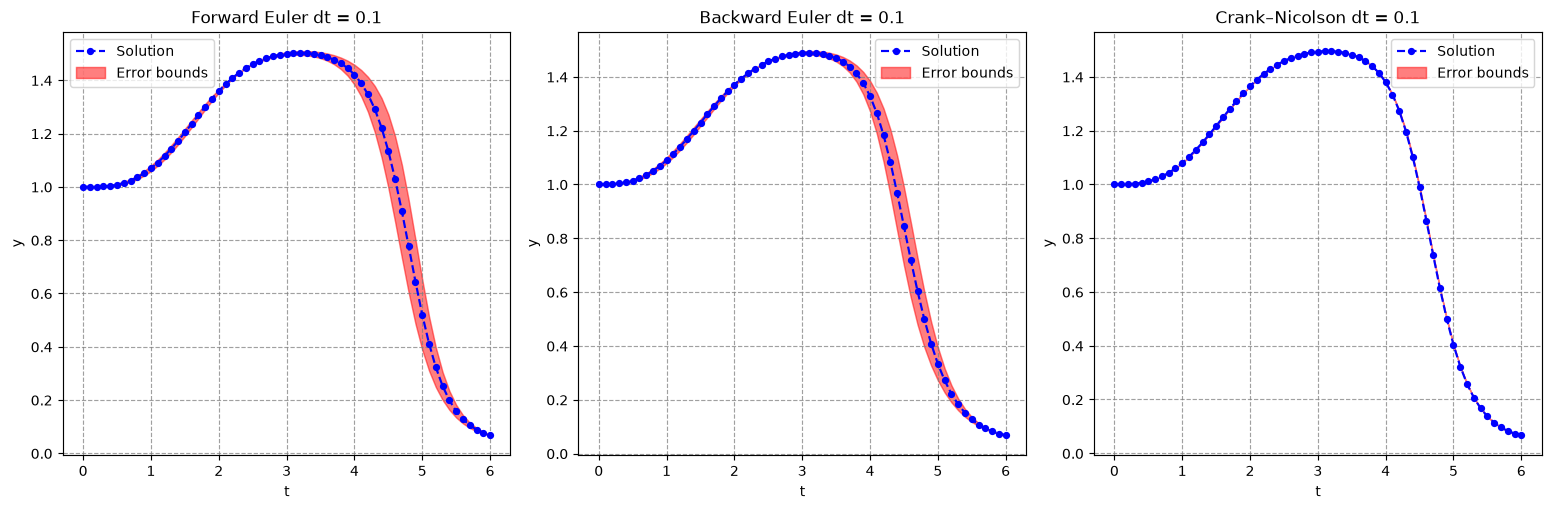

In [7]:
plot_extrapolation_results(f, t_ini, t_fin, delta_t, y_ini)

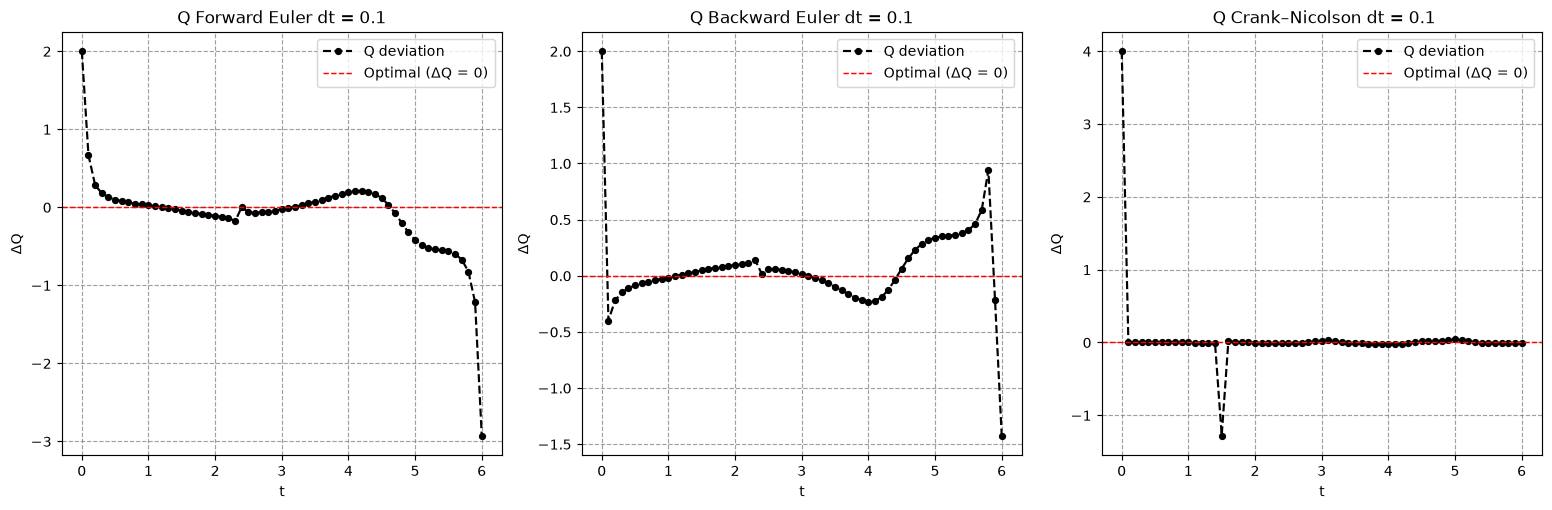

In [8]:
plot_Q(f, t_ini, t_fin, delta_t, y_ini)

Let's decrease $h$ to 0.05. See what happens

In [9]:
extrapolation(f, t_ini, t_fin, delta_t / 2.0, y_ini, method = 'forward')

(array([1.        , 1.        , 1.00003375, 1.0001686 , 1.00047136,
        1.00100792, 1.00184291, 1.0030392 , 1.00465752, 1.006756  ,
        1.00938969, 1.01261009, 1.01646465, 1.02099625, 1.02624272,
        1.03223623, 1.03900278, 1.04656167, 1.0549249 , 1.06409665,
        1.07407278, 1.08484039, 1.09637739, 1.1086523 , 1.12162404,
        1.13524202, 1.14944634, 1.1641683 , 1.17933108, 1.19485073,
        1.21063744, 1.22659697, 1.24263239, 1.25864585, 1.27454054,
        1.29022259, 1.30560291, 1.32059889, 1.33513582, 1.34914806,
        1.36257984, 1.37538575, 1.38753082, 1.3989903 , 1.40974915,
        1.41980125, 1.42914846, 1.43779951, 1.4457689 , 1.45307567,
        1.45974226, 1.46579346, 1.47125536, 1.47615445, 1.48051682,
        1.48436744, 1.48772953, 1.49062407, 1.49306928, 1.49508024,
        1.49666849, 1.49784166, 1.49860308, 1.49895142, 1.49888018,
        1.49837722, 1.49742415, 1.49599559, 1.49405837, 1.49157048,
        1.48847994, 1.48472342, 1.48022463, 1.47

In [10]:
extrapolation(f, t_ini, t_fin, delta_t / 2.0, y_ini, method = 'backward')

(array([1.        , 1.00003375, 1.00016859, 1.00047129, 1.0010077 ,
        1.00184229, 1.00303777, 1.00465459, 1.00675051, 1.0093801 ,
        1.01259425, 1.01643963, 1.02095819, 1.02618659, 1.03215567,
        1.03888986, 1.0464066 , 1.05471584, 1.06381949, 1.07371093,
        1.08437464, 1.09578587, 1.10791051, 1.12070505, 1.13411677,
        1.14808419, 1.16253764, 1.17740023, 1.1925889 , 1.20801584,
        1.22358999, 1.23921872, 1.25480958, 1.27027208, 1.28551936,
        1.30046978, 1.31504828, 1.32918749, 1.34282855, 1.3559217 ,
        1.36842645, 1.38031155, 1.39155466, 1.40214185, 1.4120668 ,
        1.42133004, 1.42993795, 1.43790181, 1.44523681, 1.45196106,
        1.45809473, 1.46365912, 1.46867591, 1.47316647, 1.47715115,
        1.48064873, 1.48367591, 1.48624674, 1.48837225, 1.4900599 ,
        1.49131314, 1.49213092, 1.49250708, 1.49242972, 1.49188049,
        1.49083364, 1.48925502, 1.48710083, 1.48431611, 1.48083303,
        1.47656886, 1.47142355, 1.46527715, 1.45

In [11]:
extrapolation(f, t_ini, t_fin, delta_t / 2.0, y_ini, method = 'CN')

(array([1.        , 1.00001688, 1.00010118, 1.00031996, 1.00073957,
        1.0014252 , 1.00244054, 1.00384727, 1.00570466, 1.00806908,
        1.01099355, 1.01452719, 1.01871475, 1.02359606, 1.02920549,
        1.03557143, 1.04271566, 1.05065287, 1.05939007, 1.06892609,
        1.07925115, 1.09034641, 1.10218376, 1.11472562, 1.12792499,
        1.14172565, 1.15606261, 1.17086278, 1.18604594, 1.20152586,
        1.21721177, 1.23300991, 1.24882531, 1.26456357, 1.28013274,
        1.29544502, 1.3104184 , 1.32497806, 1.33905747, 1.35259927,
        1.36555571, 1.37788887, 1.38957051, 1.40058166, 1.410912  ,
        1.42055899, 1.42952699, 1.43782615, 1.4454714 , 1.45248135,
        1.45887729, 1.4646822 , 1.4699199 , 1.47461421, 1.47878825,
        1.4824638 , 1.48566074, 1.48839653, 1.49068574, 1.49253966,
        1.49396581, 1.49496756, 1.49554365, 1.49568766, 1.49538746,
        1.49462447, 1.49337294, 1.49159892, 1.48925918, 1.48629984,
        1.48265486, 1.47824418, 1.47297167, 1.46

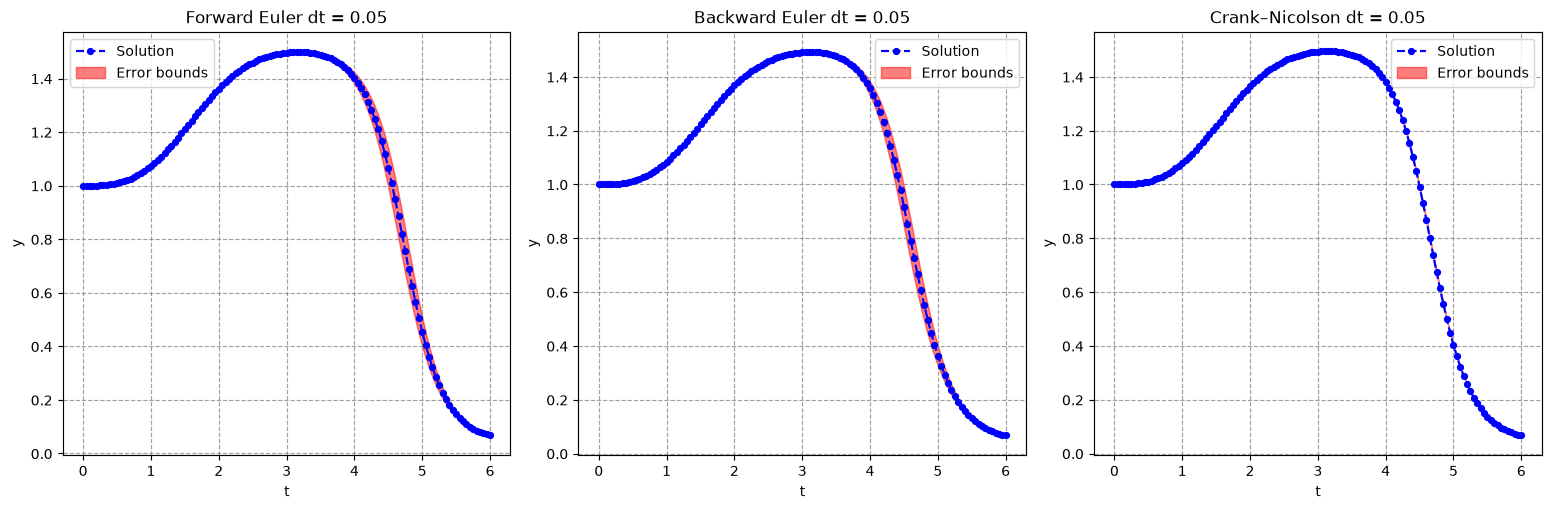

In [12]:
plot_extrapolation_results(f, t_ini, t_fin, delta_t / 2.0, y_ini)

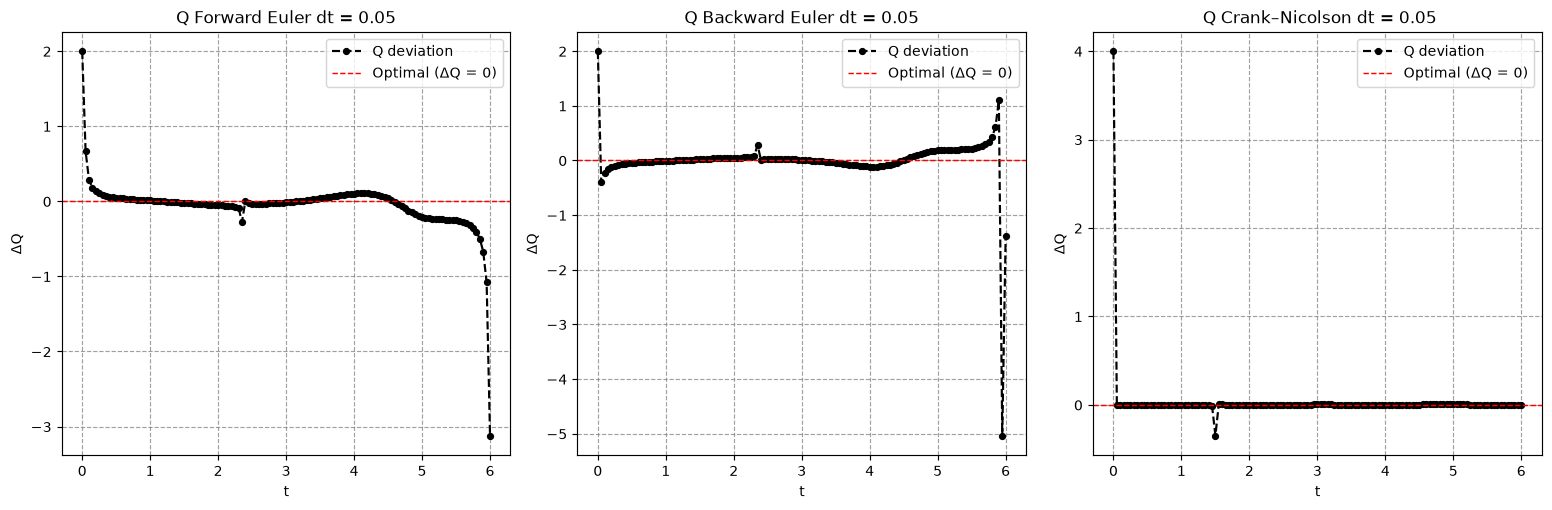

In [13]:
plot_Q(f, t_ini, t_fin, delta_t / 2.0, y_ini)